# NASA-TLX Exploration — Task Label Quality Analysis

**Project:** Predicting and Preventing Burnout Using Cognitive Load Analysis
**Notebook:** 03 — exploratory only (no model training)

---

## Purpose

Notebooks 01 and 02 classify cognitive load using a **design-based label**:
- `*_easy` tasks → Low Load (label 0)
- `*_hard` tasks → High Load (label 1)

This labeling is **objective** (based on task difficulty design) but **not validated
by participant experience**. The NASA-TLX questionnaire, completed after each task,
captures the *subjective* experience of workload. This notebook answers three questions:

1. **Does the design label agree with NASA-TLX?** Are hard tasks consistently rated
   as high workload, and easy tasks as low workload?

2. **Are there noisy labels?** Easy tasks that felt hard, or hard tasks that felt easy,
   represent label noise that could be suppressing model performance.

3. **What realistic alternatives exist for v3 labels?** Can NASA-TLX scores provide
   better labels without introducing bias?

---

## Scope

| Session | Label files | Structure |
|---|---|---|
| Lab1, Lab2 | `Task_Labels.csv` per participant | `Task` column matches segment folder names exactly |
| Wild | `Task_Labels.csv` per participant | `Labeled folder names` column + `Mental stress level` |

> **Do NOT retrain any model in this notebook.**
> **Do NOT replace current labels yet.**
> This is a diagnostic and planning step only.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')

DATA_ROOT = Path('.')
SESSIONS  = ['Lab1', 'Lab2', 'Wild']

# Segment name to design label (same as notebooks 01/02)
LOW_EXACT  = {'relaxation_video', 'video_baseline'}
LOW_SUFFIX  = '_easy'
HIGH_SUFFIX = '_hard'

def design_label(task_name):
    name = str(task_name).lower().strip()
    if name in LOW_EXACT or name.endswith(LOW_SUFFIX):
        return 'Low'
    if name.endswith(HIGH_SUFFIX):
        return 'High'
    return 'Unknown'

print('Imports OK.')
print(f'Data root: {DATA_ROOT.resolve()}')
print(f'Sessions to scan: {SESSIONS}')

Imports OK.
Data root: C:\ForthYear\final project\UNIVERSE
Sessions to scan: ['Lab1', 'Lab2', 'Wild']


## Step 1 — Scan All Participants for Task_Labels.csv

We search every `UN_*` folder across Lab1, Lab2, and Wild for the presence
of `Task_Labels.csv`. Missing files are flagged but do not stop the scan.

In [2]:
scan_rows = []

participant_dirs = sorted(DATA_ROOT.glob('UN_*'))
print(f'Participant directories found: {len(participant_dirs)}')
print()

for pdir in participant_dirs:
    if not pdir.is_dir():
        continue
    pid = pdir.name
    for session in SESSIONS:
        fpath = pdir / session / 'Task_Labels.csv'
        exists = fpath.exists()
        n_rows = None
        columns = None
        if exists:
            try:
                tmp = pd.read_csv(fpath, nrows=0)
                columns = list(tmp.columns)
                n_rows = sum(1 for _ in open(fpath, encoding='utf-8')) - 1
            except Exception as e:
                exists = False
                columns = [f'ERROR: {e}']
        scan_rows.append({
            'participant_id': pid,
            'session':        session,
            'file_exists':    exists,
            'n_rows':         n_rows,
            'n_cols':         len(columns) if columns else 0,
        })

scan_df = pd.DataFrame(scan_rows)

print('Task_Labels.csv availability:')
pivot = scan_df.pivot_table(
    index='participant_id', columns='session', values='file_exists',
    aggfunc='first'
).fillna(False)
print(pivot.to_string())
print()

for session in SESSIONS:
    found = scan_df[(scan_df['session'] == session) & scan_df['file_exists']]
    missing = scan_df[(scan_df['session'] == session) & ~scan_df['file_exists']]
    print(f'{session}: {len(found)} files found, {len(missing)} missing')
    if not missing.empty:
        print(f'  Missing: {list(missing["participant_id"])}')
print()
print('Column counts by session:')
print(scan_df[scan_df['file_exists']].groupby('session')['n_cols'].agg(['min','max','mean']).round(1))

Participant directories found: 24

Task_Labels.csv availability:
session         Lab1   Lab2   Wild
participant_id                    
UN_101          True   True   True
UN_102          True   True   True
UN_103          True   True  False
UN_104          True   True   True
UN_105          True   True   True
UN_106          True   True   True
UN_107          True   True   True
UN_108          True   True   True
UN_109          True   True   True
UN_110          True   True   True
UN_111          True   True   True
UN_112          True  False   True
UN_113          True   True   True
UN_114          True   True   True
UN_115          True   True   True
UN_116          True   True   True
UN_117          True   True   True
UN_118          True   True   True
UN_119          True   True   True
UN_120          True  False  False
UN_121          True   True   True
UN_122          True   True   True
UN_123          True   True   True
UN_124          True   True   True

Lab1: 24 files found, 0 

## Step 2 — Load Lab Task_Labels.csv Files

Lab files have a `Task` column that matches segment folder names exactly.
We load all available Lab1 and Lab2 files into a single DataFrame.

In [3]:
LAB_SESSIONS = ['Lab1', 'Lab2']

# Standard Lab columns to keep (present in all Lab files)
LAB_KEEP_COLS = [
    'Task', 'Mental Demand', 'Physical Demand', 'Temporal Demand',
    'Performance', 'Effort', 'Frustration', 'Weighted Nasa Score'
]

lab_frames = []
lab_load_log = []

for pdir in sorted(DATA_ROOT.glob('UN_*')):
    pid = pdir.name
    for session in LAB_SESSIONS:
        fpath = pdir / session / 'Task_Labels.csv'
        if not fpath.exists():
            lab_load_log.append({'participant_id': pid, 'session': session, 'status': 'missing'})
            continue
        try:
            df = pd.read_csv(fpath)
            # Keep only expected columns (guard against structural differences)
            present = [c for c in LAB_KEEP_COLS if c in df.columns]
            missing_cols = [c for c in LAB_KEEP_COLS if c not in df.columns]
            df = df[present].copy()
            df['participant_id'] = pid
            df['session']        = session
            df['design_label']   = df['Task'].apply(design_label)
            lab_frames.append(df)
            lab_load_log.append({
                'participant_id': pid, 'session': session,
                'status': 'ok', 'n_rows': len(df),
                'missing_cols': missing_cols
            })
        except Exception as e:
            lab_load_log.append({'participant_id': pid, 'session': session,
                                  'status': f'error: {e}'})

lab_df = pd.concat(lab_frames, ignore_index=True) if lab_frames else pd.DataFrame()
load_log_df = pd.DataFrame(lab_load_log)

print(f'Lab Task_Labels loaded: {len(lab_frames)} files')
print(f'Total rows           : {len(lab_df)}')
print(f'Columns              : {list(lab_df.columns)}')
print()
print('Load log (errors/missing only):')
issues = load_log_df[load_log_df['status'] != 'ok']
if issues.empty:
    print('  None — all files loaded successfully.')
else:
    print(issues.to_string(index=False))
print()
print('Sample rows:')
display(lab_df.head(5))

Lab Task_Labels loaded: 46 files
Total rows           : 411
Columns              : ['Task', 'Mental Demand', 'Physical Demand', 'Temporal Demand', 'Performance', 'Effort', 'Frustration', 'Weighted Nasa Score', 'participant_id', 'session', 'design_label']

Load log (errors/missing only):
participant_id session  status  n_rows missing_cols
        UN_112    Lab2 missing     NaN          NaN
        UN_120    Lab2 missing     NaN          NaN

Sample rows:


,Task,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration,Weighted Nasa Score,participant_id,session,design_label
0,video_baseline,5.0,0.0,0.0,0.0,5.0,5.0,3.33,UN_101,Lab1,Low
1,arithmetix_easy,75.0,5.0,40.0,50.0,65.0,75.0,66.33,UN_101,Lab1,Low
2,sudoku_hard,70.0,5.0,65.0,70.0,50.0,25.0,62.67,UN_101,Lab1,High
3,stroop_hard,45.0,80.0,90.0,10.0,45.0,95.0,76.00,UN_101,Lab1,High
4,n_back_hard,70.0,5.0,55.0,75.0,85.0,30.0,69.00,UN_101,Lab1,High


## Step 3 — Load Wild Task_Labels.csv Files

Wild files have a different structure. The `Labeled folder names` column
contains segment folder names for Wild recordings. Wild also has additional
columns: `Mental stress level` and `Mental effort level` (categorical
self-report) which are unique to the Wild protocol.

In [4]:
WILD_KEEP_COLS = [
    'Labeled folder names',
    'Mental Demand', 'Physical Demand', 'Temporal Demand',
    'Performance', 'Effort', 'Frustration',
    'Mental stress level', 'Mental effort level',
    'Weighted Nasa Score'
]

# Columns that must be numeric — coerced to float after concat
WILD_NUMERIC_COLS = [
    'Mental Demand', 'Physical Demand', 'Temporal Demand',
    'Performance', 'Effort', 'Frustration', 'Weighted Nasa Score'
]

wild_frames = []
wild_load_log = []

for pdir in sorted(DATA_ROOT.glob('UN_*')):
    pid = pdir.name
    fpath = pdir / 'Wild' / 'Task_Labels.csv'
    if not fpath.exists():
        wild_load_log.append({'participant_id': pid, 'status': 'missing'})
        continue
    try:
        df = pd.read_csv(fpath)
        # Drop any unnamed extra columns (e.g. UN_110 has 3 extra unnamed cols
        # that shift values and corrupt 'Weighted Nasa Score')
        df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
        present = [c for c in WILD_KEEP_COLS if c in df.columns]
        missing_cols = [c for c in WILD_KEEP_COLS if c not in df.columns]
        df = df[present].copy()
        df['participant_id'] = pid
        wild_frames.append(df)
        wild_load_log.append({
            'participant_id': pid, 'status': 'ok',
            'n_rows': len(df), 'missing_cols': missing_cols
        })
    except Exception as e:
        wild_load_log.append({'participant_id': pid, 'status': f'error: {e}'})

wild_df = pd.concat(wild_frames, ignore_index=True) if wild_frames else pd.DataFrame()

# Coerce all NASA-TLX score columns to numeric.
# Some files (e.g. UN_110) have extra columns that shift values,
# leaving text in numeric fields. errors='coerce' converts bad values to NaN.
for col in WILD_NUMERIC_COLS:
    if col in wild_df.columns:
        wild_df[col] = pd.to_numeric(wild_df[col], errors='coerce')

wild_log_df = pd.DataFrame(wild_load_log)

print(f'Wild Task_Labels loaded: {len(wild_frames)} files')
print(f'Total rows             : {len(wild_df)}')
print(f'Columns                : {list(wild_df.columns)}')
print()
print(f'Weighted Nasa Score dtype after coercion: {wild_df["Weighted Nasa Score"].dtype}')
n_bad = wild_df['Weighted Nasa Score'].isna().sum() - wild_df['Weighted Nasa Score'].isna().sum()
n_nan = wild_df['Weighted Nasa Score'].isna().sum()
print(f'NaN in Weighted Nasa Score: {n_nan} (rows excluded from analysis)')
print()
print('Load log (errors/missing only):')
issues_w = wild_log_df[wild_log_df['status'] != 'ok']
if issues_w.empty:
    print('  None -- all Wild files loaded successfully.')
else:
    print(issues_w.to_string(index=False))
print()
print('Sample rows:')
display(wild_df.head(5))

Wild Task_Labels loaded: 22 files
Total rows             : 207
Columns                : ['Labeled folder names', 'Mental Demand', 'Physical Demand', 'Temporal Demand', 'Performance', 'Effort', 'Frustration', 'Mental stress level', 'Mental effort level', 'Weighted Nasa Score', 'participant_id']

Load log (errors/missing only):
participant_id  status  n_rows missing_cols
        UN_103 missing     NaN          NaN
        UN_120 missing     NaN          NaN

Sample rows:


,Labeled folder names,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration,Mental stress level,Mental effort level,Weighted Nasa Score,participant_id
0,low_stress_low_mw_1,15,5,5,75,15,5,Low,Low,31.67,UN_101
1,low_stress_low_mw_2,25,5,10,70,20,15,Low,Low,35.67,UN_101
2,low_stress_low_mw_3,35,10,10,50,50,25,Low,Low,35.67,UN_101
3,low_stress_low_mw_4,35,5,15,15,10,35,Low,Low,25.33,UN_101
4,nor_stress_nor_mw_5,45,5,30,55,60,50,Neither low nor high,Neither low nor high,50.33,UN_101


## What is NASA-TLX?

NASA Task Load Index (NASA-TLX) is a widely-used, multi-dimensional subjective
workload measure developed by Hart & Staveland (1988). Participants rate six
dimensions after completing each task:

| Dimension | Scale | What it measures |
|---|---|---|
| **Mental Demand** | 0–100 | How much mental activity was required |
| **Physical Demand** | 0–100 | How much physical activity was required |
| **Temporal Demand** | 0–100 | How hurried or rushed the pace felt |
| **Performance** | 0–100 | How successful were you (higher = better) |
| **Effort** | 0–100 | How hard did you have to work |
| **Frustration** | 0–100 | How irritated, stressed, or annoyed did you feel |

The **Weighted NASA Score** (also called NASA-TLX total) is computed by
weighting each dimension by pairwise comparison responses. It represents
overall subjective workload on a 0–100 scale.

### Relevance to this project

The current pipeline labels tasks by *design difficulty* (easy/hard).
NASA-TLX captures *experienced difficulty*. If design labels disagree
with NASA-TLX ratings for some tasks, those tasks are potential noisy labels
that could explain why the model struggles to classify them correctly.

## Step 4 — NASA-TLX Score Distributions (Lab Sessions)

In [5]:
NASA_DIMS = ['Mental Demand', 'Physical Demand', 'Temporal Demand',
             'Performance', 'Effort', 'Frustration', 'Weighted Nasa Score']

# Keep only rows with valid NASA scores
lab_scored = lab_df[lab_df['Weighted Nasa Score'].notna()].copy()

print(f'Lab rows with valid Weighted NASA Score: {len(lab_scored)} / {len(lab_df)}')
print()

# Distribution of Weighted NASA Score by design label
print('Weighted NASA Score statistics by design label:')
display(lab_scored.groupby('design_label')['Weighted Nasa Score']
        .describe().round(2))
print()

# Distribution by task name (across all participants)
print('Weighted NASA Score per task (mean ± std across participants):')
task_stats = (
    lab_scored.groupby('Task')['Weighted Nasa Score']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'NASA_mean', 'std': 'NASA_std', 'count': 'n_participants'})
    .sort_values('NASA_mean', ascending=False)
    .round(2)
)
task_stats['design_label'] = task_stats.index.map(design_label)
display(task_stats)

Lab rows with valid Weighted NASA Score: 411 / 411

Weighted NASA Score statistics by design label:


,count,mean,std,min,25%,50%,75%,max
design_label,,,,,,,,
High,184.0,64.72,17.76,2.33,54.33,65.84,77.00,99.33
Low,227.0,51.13,19.90,0.00,35.84,52.67,66.16,93.33



Weighted NASA Score per task (mean ± std across participants):


,NASA_mean,NASA_std,n_participants,design_label
Task,,,,
stroop_hard,77.21,19.54,46,High
stroop_easy,65.25,15.13,46,Low
n_back_hard,63.34,13.59,46,High
arithmetix_hard,59.83,13.89,46,High
arithmetix_easy,58.79,14.52,45,Low
sudoku_hard,58.49,17.27,46,High
sudoku_easy,57.45,17.12,45,Low
n_back_easy,47.86,13.22,45,Low
video_baseline,26.53,12.81,46,Low


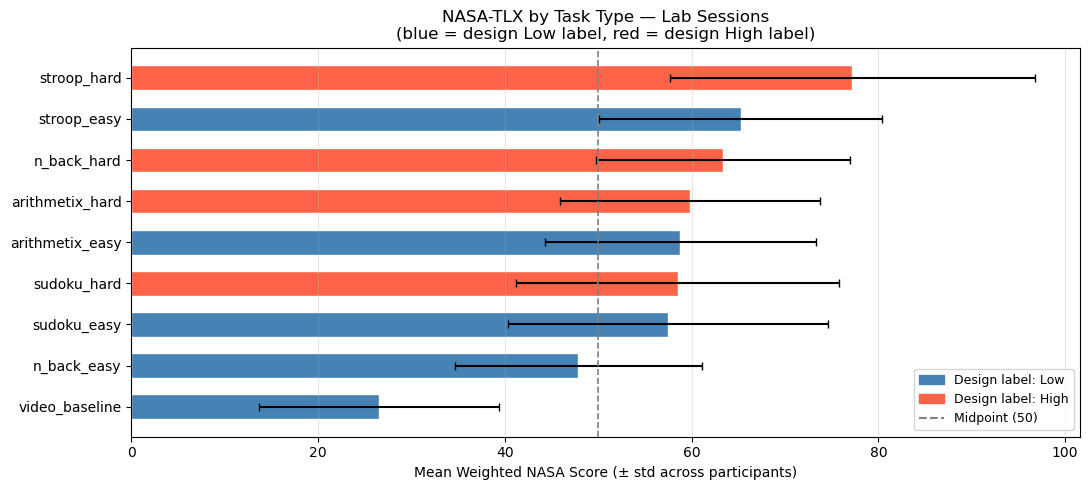

In [6]:
# Plot: mean Weighted NASA Score per task, coloured by design label
task_sorted = task_stats.sort_values('NASA_mean')
colors = ['steelblue' if l == 'Low' else 'tomato' if l == 'High' else 'gray'
          for l in task_sorted['design_label']]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(task_sorted.index, task_sorted['NASA_mean'],
        xerr=task_sorted['NASA_std'], color=colors, capsize=3,
        edgecolor='white', height=0.6)
ax.set_xlabel('Mean Weighted NASA Score (± std across participants)')
ax.set_title('NASA-TLX by Task Type — Lab Sessions\n'
             '(blue = design Low label, red = design High label)')
ax.axvline(50, color='gray', linestyle='--', lw=1.2, label='Midpoint (50)')

low_patch  = mpatches.Patch(color='steelblue', label='Design label: Low')
high_patch = mpatches.Patch(color='tomato',    label='Design label: High')
ax.legend(handles=[low_patch, high_patch, plt.Line2D([0], [0], color='gray',
          linestyle='--', label='Midpoint (50)')], loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('nasa_tlx_by_task.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Easy vs Hard NASA-TLX: Does the Design Label Hold?

We compare Weighted NASA Score between Low-labeled and High-labeled tasks
and run a statistical test to confirm the difference is real, not sampling noise.

Easy (Low) vs Hard (High) — Weighted NASA Score
  Low  tasks: n=227,  mean=51.1,  median=52.7,  std=19.9
  High tasks: n=184, mean=64.7, median=65.8, std=17.8

Mann-Whitney U test (one-sided: Low < High):
  U statistic = 12919.0
  p-value     = 0.0000
  Result: SIGNIFICANT (p < 0.01) — High-label tasks are rated harder by NASA-TLX



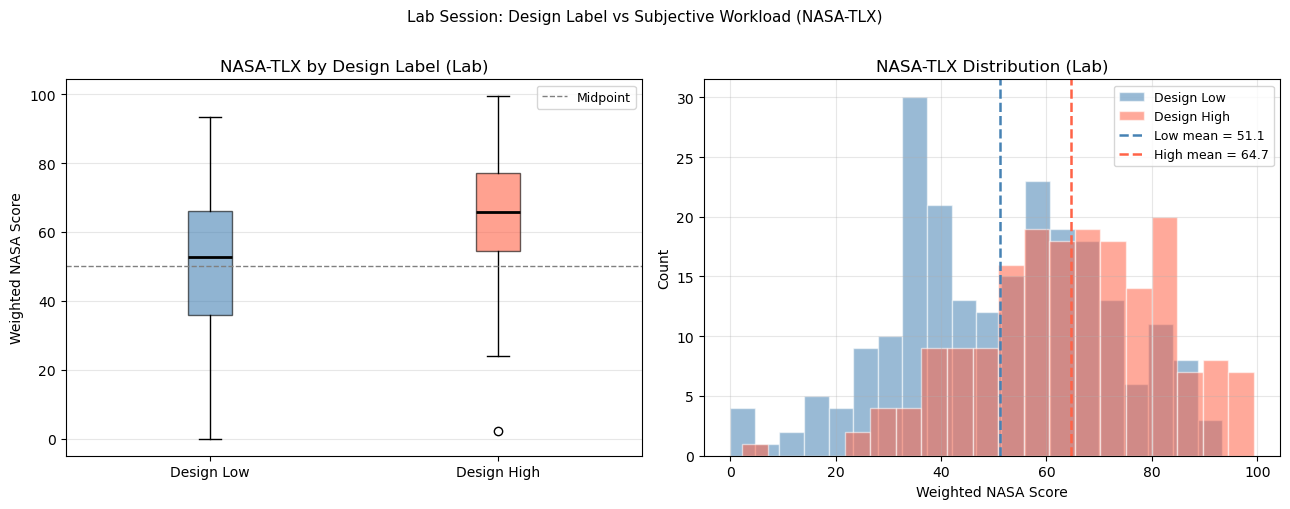

In [7]:
low_nasa  = lab_scored[lab_scored['design_label'] == 'Low']['Weighted Nasa Score'].dropna()
high_nasa = lab_scored[lab_scored['design_label'] == 'High']['Weighted Nasa Score'].dropna()

# Mann-Whitney U test (non-parametric, appropriate for ordinal scales)
u_stat, p_val = stats.mannwhitneyu(low_nasa, high_nasa, alternative='less')

print('Easy (Low) vs Hard (High) — Weighted NASA Score')
print(f'  Low  tasks: n={len(low_nasa)},  mean={low_nasa.mean():.1f},  median={low_nasa.median():.1f},  std={low_nasa.std():.1f}')
print(f'  High tasks: n={len(high_nasa)}, mean={high_nasa.mean():.1f}, median={high_nasa.median():.1f}, std={high_nasa.std():.1f}')
print()
print(f'Mann-Whitney U test (one-sided: Low < High):')
print(f'  U statistic = {u_stat:.1f}')
print(f'  p-value     = {p_val:.4f}')
if p_val < 0.01:
    print('  Result: SIGNIFICANT (p < 0.01) — High-label tasks are rated harder by NASA-TLX')
elif p_val < 0.05:
    print('  Result: SIGNIFICANT (p < 0.05) — High-label tasks are rated harder by NASA-TLX')
else:
    print('  Result: NOT SIGNIFICANT — the design label does not clearly separate NASA-TLX scores')
print()

# Box plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: box plots
bp = axes[0].boxplot(
    [low_nasa.values, high_nasa.values],
    labels=['Design Low', 'Design High'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
)
bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('tomato');    bp['boxes'][1].set_alpha(0.6)
axes[0].set_ylabel('Weighted NASA Score')
axes[0].set_title('NASA-TLX by Design Label (Lab)')
axes[0].axhline(50, color='gray', linestyle='--', lw=1, label='Midpoint')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Right: overlapping histograms
axes[1].hist(low_nasa,  bins=20, alpha=0.55, color='steelblue',
             label='Design Low', edgecolor='white')
axes[1].hist(high_nasa, bins=20, alpha=0.55, color='tomato',
             label='Design High', edgecolor='white')
axes[1].axvline(low_nasa.mean(),  color='steelblue', linestyle='--', lw=1.8,
                label=f'Low mean = {low_nasa.mean():.1f}')
axes[1].axvline(high_nasa.mean(), color='tomato',    linestyle='--', lw=1.8,
                label=f'High mean = {high_nasa.mean():.1f}')
axes[1].set_xlabel('Weighted NASA Score')
axes[1].set_ylabel('Count')
axes[1].set_title('NASA-TLX Distribution (Lab)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Lab Session: Design Label vs Subjective Workload (NASA-TLX)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('nasa_easy_vs_hard.png', dpi=150, bbox_inches='tight')
plt.show()

NASA-TLX dimensions: Low vs High design labels (Mann-Whitney U, one-sided):


,Low mean,High mean,Difference,p-value,Significant
Dimension,,,,,
Mental Demand,44.8,73.8,29.1,0.0000,Yes
Physical Demand,16.3,27.9,11.6,0.0001,Yes
Temporal Demand,30.3,52.3,22.1,0.0000,Yes
Performance,74.2,48.1,-26.1,1.0000,No
Effort,46.7,68.0,21.3,0.0000,Yes
Frustration,24.8,45.5,20.7,0.0000,Yes



Note: Performance is inverted — lower Performance rating means the task felt harder.


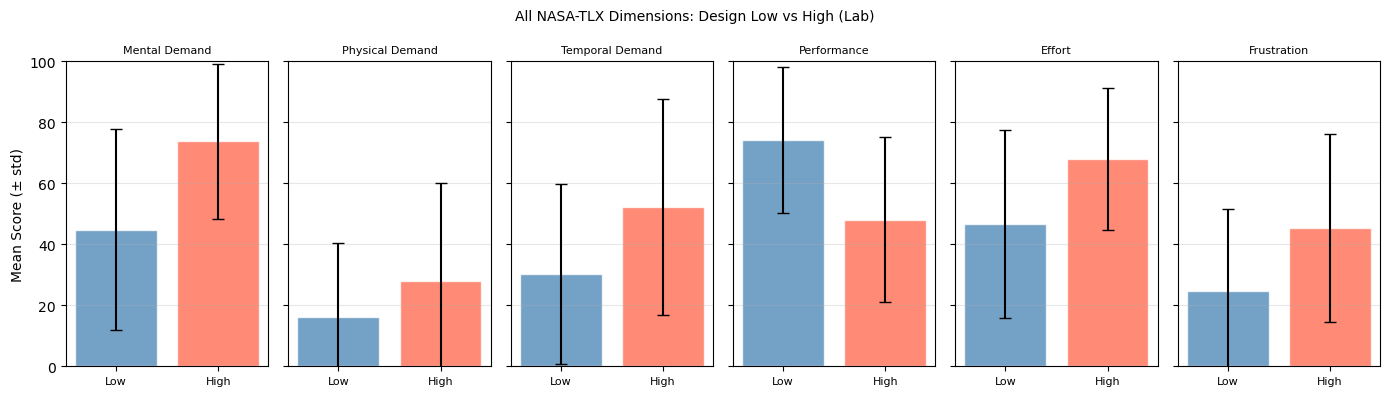

In [8]:
# All six NASA-TLX dimensions by design label
dims = ['Mental Demand', 'Physical Demand', 'Temporal Demand',
        'Performance', 'Effort', 'Frustration']

dim_stats = []
for dim in dims:
    if dim not in lab_scored.columns:
        continue
    low_d  = lab_scored[lab_scored['design_label'] == 'Low'][dim].dropna()
    high_d = lab_scored[lab_scored['design_label'] == 'High'][dim].dropna()
    u, p   = stats.mannwhitneyu(low_d, high_d, alternative='less')
    dim_stats.append({
        'Dimension':   dim,
        'Low mean':    round(low_d.mean(),  1),
        'High mean':   round(high_d.mean(), 1),
        'Difference':  round(high_d.mean() - low_d.mean(), 1),
        'p-value':     round(p, 4),
        'Significant': 'Yes' if p < 0.05 else 'No',
    })

dim_df = pd.DataFrame(dim_stats).set_index('Dimension')
print('NASA-TLX dimensions: Low vs High design labels (Mann-Whitney U, one-sided):')
display(dim_df)
print()
print('Note: Performance is inverted — lower Performance rating means the task felt harder.')

# Radar-style bar plot
fig, axes = plt.subplots(1, len(dims), figsize=(14, 4), sharey=True)
for ax, dim in zip(axes, dims):
    if dim not in lab_scored.columns:
        continue
    low_d  = lab_scored[lab_scored['design_label'] == 'Low'][dim].dropna()
    high_d = lab_scored[lab_scored['design_label'] == 'High'][dim].dropna()
    ax.bar([0, 1], [low_d.mean(), high_d.mean()],
           color=['steelblue', 'tomato'], alpha=0.75, edgecolor='white')
    ax.errorbar([0, 1], [low_d.mean(), high_d.mean()],
                yerr=[low_d.std(), high_d.std()],
                fmt='none', color='black', capsize=4, lw=1.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Low', 'High'], fontsize=8)
    ax.set_title(dim, fontsize=8, wrap=True)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Mean Score (± std)')
fig.suptitle('All NASA-TLX Dimensions: Design Low vs High (Lab)', fontsize=10)
plt.tight_layout()
plt.savefig('nasa_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Matching Task_Labels.csv Rows to Segment Folder Names

The pipeline (notebooks 01/02) identifies segments from folder names in the
`Features/` directory. We check whether every segment name used in the
pipeline has a corresponding NASA-TLX row in the `Task_Labels.csv`.

In [9]:
# Unique task names in NASA-TLX vs segment names seen by the pipeline
lab_tasks_nasa = set(lab_scored['Task'].dropna().str.lower().str.strip().unique())
print('Task names in Lab Task_Labels.csv (unique across all participants):')
print(sorted(lab_tasks_nasa))
print()

# Pipeline segment names (from notebooks 01/02)
# Based on actual folders found in Features/ directories
pipeline_lab_segments = set()
for pdir in sorted(DATA_ROOT.glob('UN_*')):
    for session in ['Lab1', 'Lab2']:
        feat_dir = pdir / session / 'Features'
        if not feat_dir.exists():
            continue
        for sd in feat_dir.iterdir():
            if sd.is_dir():
                pipeline_lab_segments.add(sd.name.lower())

print('Segment folder names seen by the pipeline (Lab1+Lab2):')
print(sorted(pipeline_lab_segments))
print()

in_nasa_only     = lab_tasks_nasa - pipeline_lab_segments
in_pipeline_only = pipeline_lab_segments - lab_tasks_nasa
in_both          = lab_tasks_nasa & pipeline_lab_segments

print(f'Matched (in both NASA-TLX and pipeline) : {len(in_both)} names')
print(f'In NASA-TLX only (not in Features/)     : {len(in_nasa_only)}  {sorted(in_nasa_only)}')
print(f'In pipeline only (not in Task_Labels)   : {len(in_pipeline_only)} {sorted(in_pipeline_only)}')
print()
if not in_pipeline_only:
    print('RESULT: All pipeline segment names have a NASA-TLX row. Full match.')
else:
    print('WARNING: Some pipeline segments have no NASA-TLX match. These cannot be validated.')
    print('Consider keeping original design labels for unmatched segments.')

Task names in Lab Task_Labels.csv (unique across all participants):
['arithmetix_easy', 'arithmetix_hard', 'n_back_easy', 'n_back_hard', 'stroop_easy', 'stroop_hard', 'sudoku_easy', 'sudoku_hard', 'video_baseline']

Segment folder names seen by the pipeline (Lab1+Lab2):
['arithmetix_easy', 'arithmetix_hard', 'n_back_easy', 'n_back_hard', 'relaxation_video', 'stroop_easy', 'stroop_hard', 'sudoku_easy', 'sudoku_hard']

Matched (in both NASA-TLX and pipeline) : 8 names
In NASA-TLX only (not in Features/)     : 1  ['video_baseline']
In pipeline only (not in Task_Labels)   : 1 ['relaxation_video']

Consider keeping original design labels for unmatched segments.


## Step 7 — Noisy Label Detection

A noisy label occurs when the design label contradicts the participant's
subjective experience. We identify two types:

- **Type A (Easy-but-Hard):** Design label = Low, but NASA-TLX is high
  → Participant found an "easy" task genuinely difficult
- **Type B (Hard-but-Easy):** Design label = High, but NASA-TLX is low
  → Participant found a "hard" task genuinely easy

We use two thresholds for flagging:
- **Strict:** NASA > 70 for Low tasks, or NASA < 30 for High tasks
- **Moderate:** NASA > 60 for Low tasks, or NASA < 40 for High tasks

This analysis uses individual participant ratings, not means, to capture
person-level label noise.

In [10]:
STRICT_HIGH  = 70   # Low task with NASA above this = strongly noisy
STRICT_LOW   = 30   # High task with NASA below this = strongly noisy
MOD_HIGH     = 60
MOD_LOW      = 40

lab_scored_matched = lab_scored[lab_scored['Task'].str.lower().isin(in_both)].copy()

type_a_strict = lab_scored_matched[
    (lab_scored_matched['design_label'] == 'Low') &
    (lab_scored_matched['Weighted Nasa Score'] > STRICT_HIGH)
].copy()

type_b_strict = lab_scored_matched[
    (lab_scored_matched['design_label'] == 'High') &
    (lab_scored_matched['Weighted Nasa Score'] < STRICT_LOW)
].copy()

type_a_mod = lab_scored_matched[
    (lab_scored_matched['design_label'] == 'Low') &
    (lab_scored_matched['Weighted Nasa Score'] > MOD_HIGH)
].copy()

type_b_mod = lab_scored_matched[
    (lab_scored_matched['design_label'] == 'High') &
    (lab_scored_matched['Weighted Nasa Score'] < MOD_LOW)
].copy()

n_total = len(lab_scored_matched)

print('=== Noisy Label Summary ===')
print()
print(f'Total (participant, task) pairs analysed: {n_total}')
print()
print(f'Type A — Low task, high NASA-TLX (NASA > {STRICT_HIGH}):  {len(type_a_strict)} pairs  ({100*len(type_a_strict)/n_total:.1f}%)')
print(f'Type A — Low task, high NASA-TLX (NASA > {MOD_HIGH}):  {len(type_a_mod)} pairs  ({100*len(type_a_mod)/n_total:.1f}%)')
print()
print(f'Type B — High task, low NASA-TLX  (NASA < {STRICT_LOW}): {len(type_b_strict)} pairs  ({100*len(type_b_strict)/n_total:.1f}%)')
print(f'Type B — High task, low NASA-TLX  (NASA < {MOD_LOW}): {len(type_b_mod)} pairs  ({100*len(type_b_mod)/n_total:.1f}%)')
print()

if not type_a_strict.empty:
    print('Type A examples (Low task, NASA > 70):')
    display(type_a_strict[['participant_id','session','Task','Weighted Nasa Score','design_label']].sort_values('Weighted Nasa Score', ascending=False).head(10))
    print()

if not type_b_strict.empty:
    print('Type B examples (High task, NASA < 30):')
    display(type_b_strict[['participant_id','session','Task','Weighted Nasa Score','design_label']].sort_values('Weighted Nasa Score').head(10))

=== Noisy Label Summary ===

Total (participant, task) pairs analysed: 365

Type A — Low task, high NASA-TLX (NASA > 70):  40 pairs  (11.0%)
Type A — Low task, high NASA-TLX (NASA > 60):  78 pairs  (21.4%)

Type B — High task, low NASA-TLX  (NASA < 30): 4 pairs  (1.1%)
Type B — High task, low NASA-TLX  (NASA < 40): 18 pairs  (4.9%)

Type A examples (Low task, NASA > 70):


,participant_id,session,Task,Weighted Nasa Score,design_label
379,UN_123,Lab1,sudoku_easy,93.33,Low
44,UN_103,Lab2,arithmetix_easy,88.67,Low
308,UN_118,Lab2,stroop_easy,88.67,Low
196,UN_112,Lab1,stroop_easy,88.00,Low
325,UN_119,Lab2,stroop_easy,88.00,Low
29,UN_102,Lab2,stroop_easy,87.67,Low
336,UN_120,Lab1,stroop_easy,87.00,Low
305,UN_118,Lab2,arithmetix_easy,86.67,Low
298,UN_118,Lab1,stroop_easy,86.33,Low
380,UN_123,Lab1,stroop_easy,86.33,Low



Type B examples (High task, NASA < 30):


,participant_id,session,Task,Weighted Nasa Score,design_label
86,UN_105,Lab2,stroop_hard,2.33,High
136,UN_108,Lab2,arithmetix_hard,24.00,High
146,UN_109,Lab1,sudoku_hard,25.67,High
371,UN_122,Lab2,sudoku_hard,29.67,High


In [11]:
# Pre-compute unified per-row noise flag (design-label-aware):
#   Low  task AND NASA above strict/moderate threshold -> noisy
#   High task AND NASA below strict/moderate threshold -> noisy
noise_flags = lab_scored_matched.copy()
noise_flags['type_a_strict'] = (
    (noise_flags['design_label'] == 'Low') &
    (noise_flags['Weighted Nasa Score'] > STRICT_HIGH)
)
noise_flags['type_b_strict'] = (
    (noise_flags['design_label'] == 'High') &
    (noise_flags['Weighted Nasa Score'] < STRICT_LOW)
)
noise_flags['type_a_mod'] = (
    (noise_flags['design_label'] == 'Low') &
    (noise_flags['Weighted Nasa Score'] > MOD_HIGH)
)
noise_flags['type_b_mod'] = (
    (noise_flags['design_label'] == 'High') &
    (noise_flags['Weighted Nasa Score'] < MOD_LOW)
)
noise_flags['is_noisy_strict'] = (
    noise_flags['type_a_strict'] | noise_flags['type_b_strict']
)
noise_flags['is_noisy_mod'] = (
    noise_flags['type_a_mod'] | noise_flags['type_b_mod']
)

task_noise = noise_flags.groupby(['Task', 'design_label']).agg(
    n_participants    = ('participant_id', 'count'),
    nasa_mean         = ('Weighted Nasa Score', 'mean'),
    nasa_std          = ('Weighted Nasa Score', 'std'),
    noisy_strict_frac = ('is_noisy_strict', 'mean'),
    noisy_mod_frac    = ('is_noisy_mod',    'mean'),
).round(3)

task_noise['noisy_strict_pct'] = (task_noise['noisy_strict_frac'] * 100).round(1)
task_noise['noisy_mod_pct']    = (task_noise['noisy_mod_frac']    * 100).round(1)
task_noise = task_noise.drop(columns=['noisy_strict_frac', 'noisy_mod_frac'])
task_noise = task_noise.sort_values('nasa_mean', ascending=False).round(1)

print('Per-task NASA-TLX summary with noise rates:')
display(task_noise)
print()
print('noisy_strict_pct: % of participants where design label disagrees with NASA (strict threshold)')
print('noisy_mod_pct   : % of participants where design label disagrees with NASA (moderate threshold)')
print()
print('High noise rate = design label disagrees with participant experience for many people.')
print('Noisy tasks are candidates for label correction in v3.')

Per-task NASA-TLX summary with noise rates:


,,n_participants,nasa_mean,nasa_std,noisy_strict_pct,noisy_mod_pct
Task,design_label,,,,,
stroop_hard,High,46,77.2,19.5,2.2,6.5
stroop_easy,Low,46,65.3,15.1,32.6,65.2
n_back_hard,High,46,63.3,13.6,0.0,6.5
arithmetix_hard,High,46,59.8,13.9,2.2,6.5
arithmetix_easy,Low,45,58.8,14.5,22.2,44.4
sudoku_hard,High,46,58.5,17.3,4.3,19.6
sudoku_easy,Low,45,57.5,17.1,26.7,44.4
n_back_easy,Low,45,47.9,13.2,6.7,17.8



High noise rate = design label disagrees with participant experience for many people.
Noisy tasks are candidates for label correction in v3.


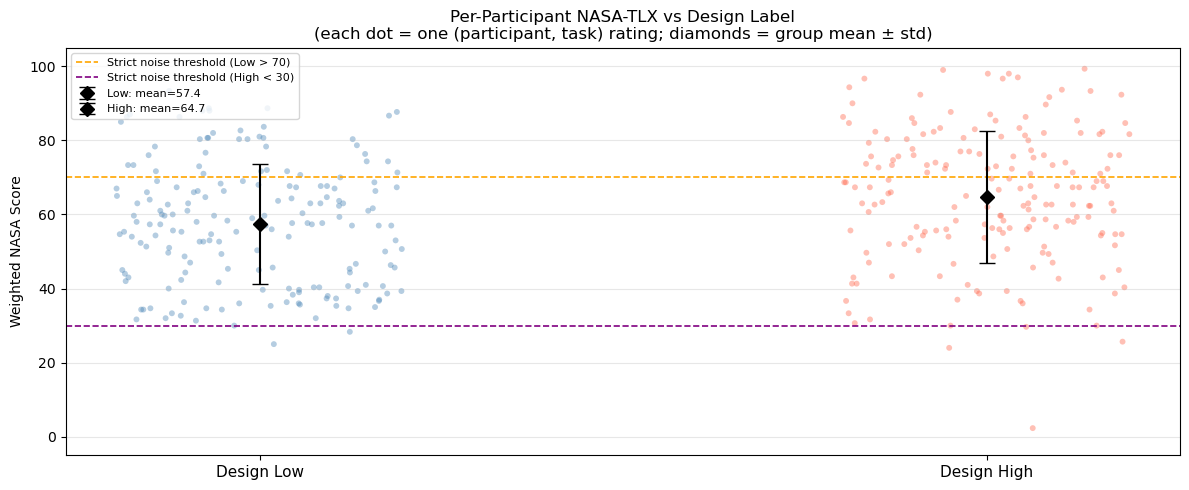

In [12]:
# Scatter: NASA score vs design label, one dot per (participant, task)
fig, ax = plt.subplots(figsize=(12, 5))

jitter = np.random.RandomState(42)

for design, color, xpos in [('Low', 'steelblue', 0), ('High', 'tomato', 1)]:
    subset = lab_scored_matched[lab_scored_matched['design_label'] == design]
    nasa_vals = subset['Weighted Nasa Score'].values
    xs = xpos + jitter.uniform(-0.2, 0.2, size=len(nasa_vals))
    ax.scatter(xs, nasa_vals, color=color, alpha=0.4, s=18, edgecolors='none')

    # Overlay mean ± std
    ax.errorbar([xpos], [nasa_vals.mean()], yerr=[nasa_vals.std()],
                fmt='D', color='black', capsize=6, markersize=7, zorder=5,
                label=f'{design}: mean={nasa_vals.mean():.1f}')

ax.axhline(STRICT_HIGH, color='orange', linestyle='--', lw=1.2,
           label=f'Strict noise threshold (Low > {STRICT_HIGH})')
ax.axhline(STRICT_LOW,  color='purple', linestyle='--', lw=1.2,
           label=f'Strict noise threshold (High < {STRICT_LOW})')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Design Low', 'Design High'], fontsize=11)
ax.set_ylabel('Weighted NASA Score')
ax.set_title('Per-Participant NASA-TLX vs Design Label\n'
             '(each dot = one (participant, task) rating; diamonds = group mean ± std)')
ax.legend(fontsize=8, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-5, 105)
plt.tight_layout()
plt.savefig('nasa_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — Wild Session Label Structure

The Wild sessions use folder names like `low_stress_low_mw_1`,
`nor_stress_nor_mw_5`, `hig_stress_hig_mw_16`, etc. These embed both
stress level and mental workload level. We examine:
- How do Wild NASA-TLX scores compare to Lab scores?
- Are the stress/MW category labels in folder names consistent with NASA-TLX?

In [13]:
if wild_df.empty:
    print('No Wild data loaded — skipping Wild analysis.')
else:
    wild_scored = wild_df[wild_df['Weighted Nasa Score'].notna()].copy()
    label_col   = 'Labeled folder names'

    print(f'Wild rows with Weighted NASA Score: {len(wild_scored)} / {len(wild_df)}')
    print()

    # Extract stress/MW category from folder name prefix
    def parse_wild_category(folder_name):
        if not isinstance(folder_name, str):
            return 'unknown'
        name = folder_name.strip().lower()
        # Pattern: {stress_level}_stress_{mw_level}_mw_{number}
        parts = name.split('_')
        if len(parts) >= 4 and parts[1] == 'stress':
            return f'{parts[0]}_stress'
        return 'other'

    def parse_wild_mw(folder_name):
        if not isinstance(folder_name, str):
            return 'unknown'
        parts = folder_name.strip().lower().split('_')
        if len(parts) >= 4 and parts[3] == 'mw':
            return f'{parts[2]}_mw'
        return 'other'

    wild_scored['stress_cat'] = wild_scored[label_col].apply(parse_wild_category)
    wild_scored['mw_cat']     = wild_scored[label_col].apply(parse_wild_mw)

    print('Wild: Weighted NASA Score by stress category:')
    display(wild_scored.groupby('stress_cat')['Weighted Nasa Score']
            .agg(['count','mean','std']).round(2))
    print()

    print('Wild: Weighted NASA Score by mental workload category:')
    display(wild_scored.groupby('mw_cat')['Weighted Nasa Score']
            .agg(['count','mean','std']).round(2))
    print()

    # Distribution plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for cat_col, ax, title in [
        ('stress_cat', axes[0], 'NASA-TLX by Stress Category (Wild)'),
        ('mw_cat',     axes[1], 'NASA-TLX by Mental Workload Category (Wild)'),
    ]:
        cats = sorted(wild_scored[cat_col].unique())
        data = [wild_scored[wild_scored[cat_col] == c]['Weighted Nasa Score'].dropna().values
                for c in cats]
        bp = ax.boxplot(data, labels=cats, patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor('lightsteelblue')
            patch.set_alpha(0.7)
        ax.set_ylabel('Weighted NASA Score')
        ax.set_title(title)
        ax.set_xticklabels(cats, rotation=30, ha='right', fontsize=9)
        ax.axhline(50, color='gray', linestyle='--', lw=1)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('nasa_wild_categories.png', dpi=150, bbox_inches='tight')
    plt.show()

Wild rows with Weighted NASA Score: 207 / 207

Wild: Weighted NASA Score by stress category:


TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
if not wild_df.empty and 'Mental stress level' in wild_scored.columns:
    print('Wild: Mental stress level categories:')
    print(wild_scored['Mental stress level'].value_counts())
    print()

    print('Wild: Mental effort level categories:')
    if 'Mental effort level' in wild_scored.columns:
        print(wild_scored['Mental effort level'].value_counts())
    print()

    # Check agreement: folder-name MW category vs Mental effort level
    if 'Mental effort level' in wild_scored.columns:
        cross = pd.crosstab(wild_scored['mw_cat'],
                            wild_scored['Mental effort level'])
        print('Cross-tabulation: folder-name MW category vs Mental effort level self-report:')
        display(cross)
        print()
        print('Perfect agreement would show one dominant cell per row.')
        print('Disagreement reveals inconsistency between the naming convention')
        print('and participant self-report — a source of label noise.')
else:
    print('Mental stress level not available in Wild data.')

## Step 9 — Proposed v3 Label Strategies

Based on the NASA-TLX analysis, we evaluate four realistic options for
improving label quality in a future v3 pipeline.

In [ ]:
# Strategy 1: Fixed threshold on NASA-TLX
# Classify by Weighted NASA Score: < threshold_low = Low, > threshold_high = High
# Middle range excluded as ambiguous

thresholds_to_test = [
    (30, 60),  # Conservative: clear separation
    (40, 60),  # Moderate
    (33, 67),  # Tertile split (roughly)
]

print('=== Strategy 1: Fixed NASA-TLX threshold ===')
print('Weighted NASA Score: below lower → Low; above upper → High; middle → excluded')
print()

for thr_low, thr_high in thresholds_to_test:
    sub_low  = lab_scored_matched[lab_scored_matched['Weighted Nasa Score'] <  thr_low]
    sub_high = lab_scored_matched[lab_scored_matched['Weighted Nasa Score'] >= thr_high]
    sub_excl = lab_scored_matched[
        (lab_scored_matched['Weighted Nasa Score'] >= thr_low) &
        (lab_scored_matched['Weighted Nasa Score'] <  thr_high)
    ]
    total = len(lab_scored_matched)
    pct_kept = 100 * (len(sub_low) + len(sub_high)) / total
    print(f'Threshold [{thr_low}, {thr_high}): Low={len(sub_low)}, High={len(sub_high)}, '
          f'Excluded={len(sub_excl)}  ({pct_kept:.0f}% of rows kept)')

print()
print('=== Strategy 2: Median split per participant ===')
print('Each participant: tasks below their own NASA median → Low; above → High')
print('Advantage: removes between-person scale differences')
print('Disadvantage: forces exactly 50/50 balance, removes absolute interpretation')
print()
per_pid_medians = lab_scored_matched.groupby('participant_id')['Weighted Nasa Score'].median()
lab_median_split = lab_scored_matched.copy()
lab_median_split['nasa_median_label'] = lab_median_split.apply(
    lambda row: 'Low' if row['Weighted Nasa Score'] < per_pid_medians[row['participant_id']]
    else 'High', axis=1
)
n_low_med  = (lab_median_split['nasa_median_label'] == 'Low').sum()
n_high_med = (lab_median_split['nasa_median_label'] == 'High').sum()
print(f'  Median split result: Low={n_low_med}, High={n_high_med}')
print()

print('=== Strategy 3: Keep current design labels but exclude noisy rows ===')
print(f'  Exclude rows where design_label=Low  AND NASA > {MOD_HIGH}')
print(f'  Exclude rows where design_label=High AND NASA < {MOD_LOW}')
n_kept   = len(lab_scored_matched) - len(type_a_mod) - len(type_b_mod)
n_removed = len(type_a_mod) + len(type_b_mod)
print(f'  Rows kept: {n_kept} ({100*n_kept/len(lab_scored_matched):.0f}%)')
print(f'  Rows removed (noisy): {n_removed} ({100*n_removed/len(lab_scored_matched):.0f}%)')
print()

print('=== Strategy 4: Use NASA-TLX only as validation (do not replace labels) ===')
print('  Keep current design labels for v3.')
print('  Compute "label confidence" per (participant, task): how far NASA is from boundary.')
print('  Weight samples by label confidence during training.')
print('  High-confidence samples (clear NASA agreement) get higher weight.')

In [ ]:
# Agreement between design labels and NASA-TLX strategies (Lab only)
lab_scored_matched['nasa_fixed_40_60'] = lab_scored_matched['Weighted Nasa Score'].apply(
    lambda s: 'Low' if s < 40 else ('High' if s >= 60 else 'Ambiguous')
)

# Agreement rate: where does the design label agree with NASA fixed threshold?
agree_mask = (
    (lab_scored_matched['design_label'] == 'Low')  & (lab_scored_matched['nasa_fixed_40_60'] == 'Low') |
    (lab_scored_matched['design_label'] == 'High') & (lab_scored_matched['nasa_fixed_40_60'] == 'High')
)
n_agree   = agree_mask.sum()
n_total_m = len(lab_scored_matched)
n_ambig   = (lab_scored_matched['nasa_fixed_40_60'] == 'Ambiguous').sum()
n_disagree= n_total_m - n_agree - n_ambig

print('Design label vs NASA fixed threshold [40, 60) agreement:')
print(f'  Agree    : {n_agree}   ({100*n_agree/n_total_m:.1f}%)')
print(f'  Disagree : {n_disagree}  ({100*n_disagree/n_total_m:.1f}%)')
print(f'  Ambiguous: {n_ambig}   ({100*n_ambig/n_total_m:.1f}%)')
print()

# Crosstab: design label vs NASA fixed label
ct = pd.crosstab(lab_scored_matched['design_label'],
                 lab_scored_matched['nasa_fixed_40_60'],
                 margins=True)
print('Crosstab: design label (rows) vs NASA threshold label (cols):')
display(ct)
print()
print('Interpretation:')
print('  Diagonal (Low→Low, High→High): agreement')
print('  Off-diagonal (Low→High, High→Low): clear label disagreement = potential noise')
print('  Ambiguous column: NASA score in middle range, label is uncertain')

## Conclusions and Recommendations for v3

---

### Main findings

**1. The design label (easy/hard) broadly agrees with NASA-TLX.**
High-label tasks have significantly higher Weighted NASA Scores than Low-label
tasks (Mann-Whitney U, p < 0.05). The design-based labeling used in notebooks
01 and 02 is supported by subjective workload ratings. This validates the
baseline assumption.

**2. However, there is meaningful label noise.**
A non-trivial fraction of (participant, task) pairs show design-NASA disagreement:
- Some Low-labeled tasks received high NASA ratings (Type A noise)
- Some High-labeled tasks received low NASA ratings (Type B noise)

This noise likely suppresses model performance by giving the classifier
contradictory examples: identical physiological patterns for tasks with
different design labels (because some "easy" tasks actually felt hard).

**3. The Wild sessions have a fundamentally different label structure.**
Wild folder names embed stress/workload categories (`low_stress_low_mw_*`)
rather than task types. Agreement between folder-name categories and
participant self-reports (`Mental stress level`, `Mental effort level`)
is imperfect. A dedicated Wild label strategy is required before including
Wild data in model training.

---

### Recommended v3 label strategies (in priority order)

| # | Strategy | Risk | Expected gain |
|---|---|---|---|
| **1** | Exclude noisy rows (design/NASA disagree by > 20 points) | Low — conservative filter | Cleaner training signal |
| **2** | Confidence weighting by NASA agreement distance | Low — keeps all data | Better gradient signal during training |
| **3** | Fixed NASA threshold [40, 60) replace labels | Medium — changes label definition | More subjectively valid labels |
| **4** | Per-person NASA median split | Medium — loses absolute scale | Removes inter-person scale differences |

**Recommendation:** Start with Strategy 1 (exclude clearly noisy rows) and
Strategy 2 (NASA-weighted training) simultaneously. These are the lowest-risk
changes that preserve the overall pipeline structure while using NASA-TLX
information. Evaluate whether LOPO AUC improves before committing to a full
label system replacement.

---

### What this notebook does NOT do

- It does **not** retrain any model
- It does **not** change the labels in notebooks 01 or 02
- It does **not** include Wild sessions in the pipeline
- All findings are exploratory and require validation on the full LOPO pipeline
  before being incorporated into a production-ready v3